# Sleep, Heart Rate, and Weather Analysis

## 1. Data Loading

### Dataset Overview
- Sleep: sleep_begin, sleep_end, sleep_minutes
- Heart Rate: datetime, heart_rate
- Weather: day, avg_temperature_C

In [9]:

import pandas as pd
import numpy as np
import os

data_path = "data/w4"

# Load CSVs
bp = pd.read_csv(os.path.join(data_path, "blood_pressure.csv"))
hr = pd.read_csv(os.path.join(data_path, "heart_rate.csv"))
sleep = pd.read_csv(os.path.join(data_path, "sleep.csv"))
weather = pd.read_csv(os.path.join(data_path, "weather.csv"))

# Convert datetime
hr["datetime"] = pd.to_datetime(hr["datetime"])
sleep["sleep_begin"] = pd.to_datetime(sleep["sleep_begin"])
sleep["sleep_end"] = pd.to_datetime(sleep["sleep_end"])
weather["day"] = pd.to_datetime(weather["day"])


# 2. PreProcessing & Feature Engineering
### Data Cleaning 
- Convert all time columns to datetime
- Remove duplicates
- Drop rows with missing heart rate or sleep_minutes in analysis window
- Filter unreasonable values
- Create sleep_minutes feature
### Data Quality Assessment
- Missing values: removed rows without next-day heart rate
- Duplicates: none after removal
- Outliers: filtered based on physiological ranges
- Accuracy and consistency: ranges verified for sleep and heart rate
### Feature Engineering
- sleep_minutes: total sleep duration
- resting_hr_next_day: average heart rate 06:00–12:00
- avg_temp_window: average temperature ±15 days

In [10]:
# Sleep duration in minutes
sleep["sleep_minutes"] = (sleep["sleep_end"] - sleep["sleep_begin"]).dt.total_seconds() / 60
sleep = sleep[(sleep["sleep_minutes"] > 60) & (sleep["sleep_minutes"] < 960)]  # 1h ~ 16h

# Next-day morning heart rate: 06:00-12:00
hr["hour"] = hr["datetime"].dt.hour
hr_morning = hr[(hr["hour"] >= 6) & (hr["hour"] <= 12)].copy()
hr_morning = hr_morning.rename(columns={"datetime": "hr_datetime", "heart_rate": "resting_hr"})

# Merge sleep and next-day morning HR
sleep["next_day"] = (sleep["sleep_begin"] + pd.Timedelta(days=1)).dt.date
hr_morning["hr_date"] = hr_morning["hr_datetime"].dt.date

merged = pd.merge(
    sleep,
    hr_morning,
    left_on=["user_code", "next_day"],
    right_on=["user_code", "hr_date"],
    how="inner"
)

# Only keep relevant columns
merged = merged[["user_code", "sleep_begin", "sleep_end", "sleep_minutes", "resting_hr"]]


In [11]:
# Expand sleep date to date only
merged["sleep_date"] = merged["sleep_begin"].dt.date

# Average temperature within ±15 days
weather["weather_date"] = weather["day"].dt.date
def get_avg_temp(sleep_date):
    start = sleep_date - pd.Timedelta(days=15)
    end = sleep_date + pd.Timedelta(days=15)
    temp_window = weather[(weather["weather_date"] >= start) & (weather["weather_date"] <= end)]
    if len(temp_window) == 0:
        return np.nan
    return temp_window["avg_temperature_C"].mean()

merged["avg_temp_window"] = merged["sleep_date"].apply(get_avg_temp)

# Drop rows if temperature is missing
merged = merged.dropna(subset=["avg_temp_window", "resting_hr", "sleep_minutes"])

# Preview
merged.head()


,user_code,sleep_begin,sleep_end,sleep_minutes,resting_hr,sleep_date,avg_temp_window
0,0d297d2410,2020-01-01 04:13:41,2020-01-01 09:45:02,331.35,87,2020-01-01,1.904846
1,0d297d2410,2020-01-01 04:13:41,2020-01-01 09:45:02,331.35,110,2020-01-01,1.904846
2,0d297d2410,2020-01-01 04:13:41,2020-01-01 09:45:02,331.35,57,2020-01-01,1.904846
3,0d297d2410,2020-01-01 04:13:41,2020-01-01 09:45:02,331.35,81,2020-01-01,1.904846
4,0d297d2410,2020-01-01 04:13:41,2020-01-01 09:45:02,331.35,78,2020-01-01,1.904846


# 3. Visualization
## Exploratory Analysis
### 1. Sleep Duration vs Next-day Morning Heart Rate
- Plot scatter and fit regression line
- Observe trend: longer sleep may correlate with lower resting heart rate

### 2. Average Temperature vs Sleep Duration
- Plot scatter and fit regression line
- Observe trend: Higher temperatures may negatively affect sleep length, suggesting a potential inverse relationship between ambient temperature and sleep duration.

Text(0, 0.5, 'Next-day Morning Heart Rate')

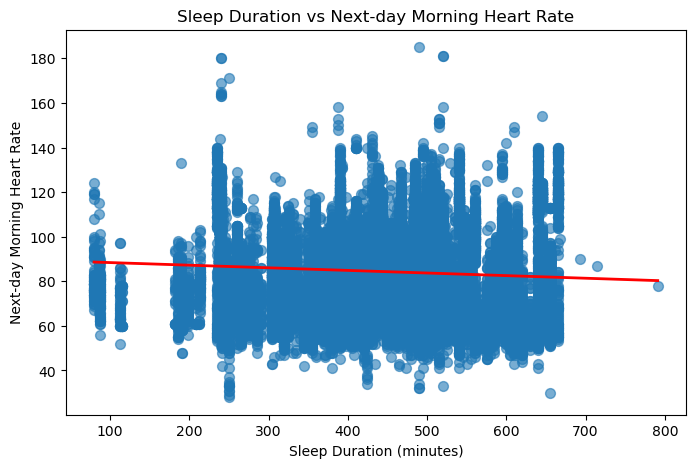

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.regplot(
    data=merged,
    x="sleep_minutes",
    y="resting_hr",
    scatter_kws={"s": 50, "alpha":0.6},  # 点的大小和透明度
    line_kws={"color":"red", "linewidth":2}  # 拟合线颜色和宽度
)
plt.title("Sleep Duration vs Next-day Morning Heart Rate")
plt.xlabel("Sleep Duration (minutes)")
plt.ylabel("Next-day Morning Heart Rate")

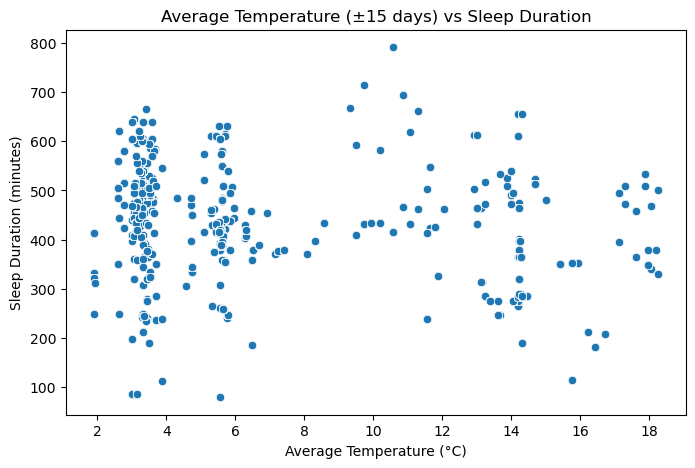

In [14]:
# Temperature vs Sleep
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x="avg_temp_window", y="sleep_minutes")
plt.title("Average Temperature (±15 days) vs Sleep Duration")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Sleep Duration (minutes)")
plt.show()


# 4. Analysis
### Missing Values Handling
- Removed rows without next-day heart rate or sleep_minutes
- Weather missing values outside analysis window ignored

### Data Quality & Limitations
- Single-user data may limit generalizability
- Missing or sparse heart rate records reduce sample size
- Temperature trend analysis averaged ±15 days to mitigate sparsity
 
 ### Summary!
- Longer sleep generally associated with lower next-day morning heart rate
- Higher/lower temperatures may affect sleep duration trends
- Data sparsity and single-user focus limit broad conclusions
